# Assignment 1 2AMM10 2025-2026

## Group: tokenmaxxing
### Member 1: Joana Lopes
### Member 2: Keanu Lim A Po
### Member 3: Melissa Maistro

In [ ]:
import torch
import json
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np

## Global Variables ##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DATA_DIR = "./data"
DROWSY_DATASET_DIR = Path(
    DATA_DIR, "drowsy_graph_dataset"
)  # Path to the drowsy dataset
OBJ_CLS_DATASET_DIR = Path(
    DATA_DIR, "/content/drive/MyDrive/Autonomous-Driving-using-Deep-Learning/data/bdd8cls_balanced_300_30"
)  # Path to the object classification dataset
DEVICE = (
    torch.DEVICE("cuda")
    if torch.cuda.is_available()
    else (
        torch.DEVICE("mps")
        if torch.backends.mps.is_available()
        else torch.DEVICE("cpu")
    )
)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Task 1

In [ ]:
class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train"):
        self.root = Path(root)
        self.split = split

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]


train_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")
class_to_id: dict = train_dataset.class_to_id
id_to_class: dict = train_dataset.id_to_class

##

<Axes: >

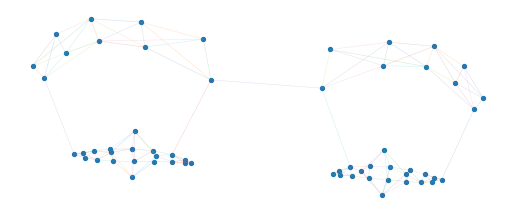

In [ ]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax


fig, ax = plt.subplots()
idx = random.randint(0, len(train_dataset) - 1)
graph = train_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax)


# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.

# Task 2

In [8]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        self.labels = (
            pd.read_csv(self.labels_path, header=None).iloc[:, 0].astype(int).tolist()
        )

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img

In [44]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.transforms import Compose, ToTensor, Resize, Normalize
from sklearn.metrics import precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
IMG_SIZE    = 64
PATCH_SIZE  = 8
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2   # 64 patches
EMBED_DIM   = 128
NUM_HEADS   = 4
NUM_LAYERS  = 4
MLP_DIM     = 256
DROPOUT     = 0.1
NUM_CLASSES = 8
BATCH_SIZE  = 64
EPOCHS      = 30
LR          = 3e-4

In [45]:
# Compute dataset mean and std from training data
raw_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=Compose([Resize((IMG_SIZE, IMG_SIZE)), ToTensor()]),
)
raw_loader = DataLoader(raw_dataset, batch_size=64, shuffle=False)

mean = torch.zeros(3)
std  = torch.zeros(3)
for imgs, _ in raw_loader:
    # imgs: [B, C, H, W] — average over batch, height, width; keep channel dim
    mean += imgs.mean(dim=[0, 2, 3])
    std  += imgs.std(dim=[0, 2, 3])

mean /= len(raw_loader)
std  /= len(raw_loader)
print(f"mean : {mean.tolist()}")
print(f"std  : {std.tolist()}")
MEAN = mean.tolist()
STD  = std.tolist()

# Transformations: train on uncorrupted images, test on corrupted and evaluate on clean test set
train_transform = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor(),
    Normalize(mean=MEAN, std=STD),
])

test_transform_noisy = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor(),
    PatchShuffle(patch_size=PATCH_SIZE),   # PatchShuffle AFTER ToTensor because PatchShuffle expects a tensor [C,H,W]
    Normalize(mean=MEAN, std=STD),
])

# same as training, no corruption
test_transform_clean = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor(),
    Normalize(mean=MEAN, std=STD),
])

mean : [0.31468892097473145, 0.31967535614967346, 0.30785417556762695]
std  : [0.22667554020881653, 0.22608275711536407, 0.21855732798576355]



Class names: ['person', 'rider', 'car', 'truck', 'bus', 'bike', 'traffic light', 'traffic sign']
Train: 2400
Test: 240


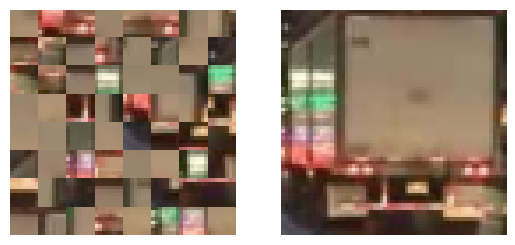

In [14]:
train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=train_transform,
)

test_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=test_transform_noisy,
)

test_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=test_transform_clean,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader_noisy = DataLoader(test_dataset_noisy, batch_size=BATCH_SIZE, shuffle=False)
test_loader_clean = DataLoader(test_dataset_clean, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
print(f"\nClass names: {class_names}")
print(f"Train: {len(train_dataset)}")
print(f"Test: {len(test_dataset_noisy)}")


### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
from torchvision.transforms import Compose, ToTensor, Resize
from torchvision.transforms import functional as vf
import matplotlib.pyplot as plt

vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)
fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(vf.to_pil_image(img_noisy))
ax[1].imshow(vf.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
#### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###

In [46]:
# 1. design and train a suitable neural-network architecture for this task using uncorrupted training images, and evaluate it on corrupted test images.



# Architecture: Vision Transformer (ViT) without positional embeddings
#
# WHY ViT?
#   PatchShuffle randomises patch positions, so any model that relies on spatial structure (e.g. a CNN) will fail at test time.
#   A ViT without positional embeddings treats patches as an UNORDERED SET:
#     - PatchEmbedding: same linear layer maps every patch's pixels → vector,
#       regardless of where the patch came from in the image.
#     - Self-attention: score(i,j) = Q_i · K_j depends only on patch content,
#       not on sequence index → permutation-equivariant.
#     - CLS token: aggregates information from all patches via attention,
#       replacing global pooling (which is explicitly banned).
#   Result: shuffling patches at test time produces the same CLS output as any other ordering → the model is invariant to PatchShuffle.

class PatchEmbedding(nn.Module):
    """
    Cuts [B, C, H, W] into N non-overlapping pxp patches and projects
    each flat patch vector (C*p*p dims) to embed_dim via a shared linear layer.

    'Shared' means the same weights are applied to every patch slot —
    the model cannot tell patch 3 from patch 47 by position alone.
    No positional embeddings are added, so patch order is invisible to
    everything that follows.
    """
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.patch_size  = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        patch_dim        = in_channels * patch_size * patch_size  # 3*8*8 = 192
        self.projection  = nn.Linear(patch_dim, embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.unfold(2, p, p).unfold(3, p, p)
        x = x.contiguous().view(B, C, -1, p, p)
        x = x.permute(0, 2, 1, 3, 4)
        x = x.contiguous().view(B, self.num_patches, -1)
        return self.projection(x)


class MultiHeadSelfAttention(nn.Module):
    """
    Each token attends to every other token. The score between tokens i and j
    is Q_i · K_j / sqrt(d), which depends only on content, not on position.
    Shuffling the patch sequence permutes the outputs the same way, so the
    CLS token (which attends to all patches) produces the same result regardless
    of patch order.
    """
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(embed_dim, 3 * embed_dim)
        self.out_proj  = nn.Linear(embed_dim, embed_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        B, T, D = x.shape
        qkv = self.qkv(x).view(B, T, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = self.dropout(attn.softmax(dim=-1))
        x = (attn @ v).transpose(1, 2).contiguous().view(B, T, D)
        return self.out_proj(x)


class TransformerBlock(nn.Module):
    """
    Pre-LN block: LayerNorm → sub-layer → residual connection.
    Pre-LN (norm before attention/MLP) is more stable than the original
    post-LN formulation. Residual connections allow gradients to flow
    directly through many layers without vanishing.
    GELU activation is standard in modern Transformers (smoother than ReLU).
    """
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))   # attention + residual
        x = x + self.mlp(self.norm2(x))    # MLP + residual
        return x


class ViT(nn.Module):
    """
    Vision Transformer without positional embeddings.
    Flow: image → N patch embeddings → prepend CLS → Transformer → CLS output → linear head
    """
    def __init__(self, img_size, patch_size, in_channels,
                 embed_dim, num_heads, num_layers, mlp_dim,
                 num_classes, dropout=0.0):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.dropout     = nn.Dropout(dropout)
        self.transformer = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        B = x.shape[0]
        x   = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = self.dropout(torch.cat([cls, x], dim=1))
        x   = self.transformer(x)
        x   = self.norm(x[:, 0])
        return self.head(x)

model = ViT(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    embed_dim=EMBED_DIM, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    mlp_dim=MLP_DIM, num_classes=NUM_CLASSES, dropout=DROPOUT,
).to(DEVICE)

Epoch   1/30 | Train loss 2.0309  acc 0.187 | Test(noisy) loss 1.9740  acc 0.225
Epoch   5/30 | Train loss 1.8027  acc 0.294 | Test(noisy) loss 1.8152  acc 0.292
Epoch  10/30 | Train loss 1.5388  acc 0.436 | Test(noisy) loss 1.6683  acc 0.392
Epoch  15/30 | Train loss 1.3613  acc 0.498 | Test(noisy) loss 1.5622  acc 0.429
Epoch  20/30 | Train loss 1.1984  acc 0.566 | Test(noisy) loss 1.5818  acc 0.433
Epoch  25/30 | Train loss 1.0829  acc 0.612 | Test(noisy) loss 1.5181  acc 0.458
Epoch  30/30 | Train loss 1.0325  acc 0.632 | Test(noisy) loss 1.5293  acc 0.463


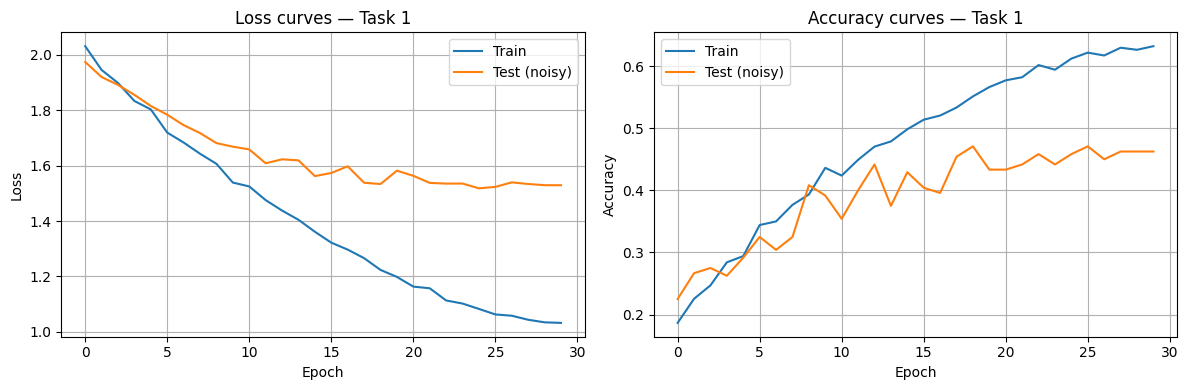

In [47]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def train_one_epoch(model, loader, optimizer, criterion, DEVICE):
    model.train()
    total_loss, total_correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        total_correct += (logits.argmax(1) == labels).sum().item()
        n += imgs.size(0)
    return total_loss / n, total_correct / n


@torch.no_grad()
def evaluate(model, loader, criterion, DEVICE):
    model.eval()
    total_loss, total_correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        total_correct += (logits.argmax(1) == labels).sum().item()
        n  += imgs.size(0)
    return total_loss / n, total_correct / n

train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    te_loss, te_acc = evaluate(model, test_loader_noisy, criterion, DEVICE) # Evaluate on NOISY test set
    scheduler.step()

    train_losses.append(tr_loss); train_accs.append(tr_acc)
    test_losses.append(te_loss);  test_accs.append(te_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss {tr_loss:.4f}  acc {tr_acc:.3f} | "
              f"Test(noisy) loss {te_loss:.4f}  acc {te_acc:.3f}")

# training & test loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="Train")
axes[0].plot(test_losses,  label="Test (noisy)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss curves — Task 1"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(train_accs, label="Train")
axes[1].plot(test_accs,  label="Test (noisy)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy curves — Task 1"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

In [48]:
# 2. compute the same two evaluation metrics introduced in Task 1, for each object classindividually.


# Recall    (per class c) = TP_c / (TP_c + FN_c)
#   Of all images truly belonging to class c, what fraction did the
#   model correctly predict as c?  → measures how much we miss
#
# Precision (per class c) = TP_c / (TP_c + FP_c)
#   Of all images the model predicted as c, what fraction truly are c?
#   → measures how reliable positive predictions are
#
# Evaluated on the NOISY (PatchShuffled) test set


@torch.no_grad()
def get_preds_and_labels(model, loader, DEVICE):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

preds_noisy, labels_noisy = get_preds_and_labels(model, test_loader_noisy, DEVICE)


precision_per_class = precision_score(
    labels_noisy, preds_noisy, average=None, zero_division=0
)
recall_per_class = recall_score(
    labels_noisy, preds_noisy, average=None, zero_division=0
)

print("\nPer-class metrics (noisy test set):")
print(f"{'Class':<15} {'Precision':>10} {'Recall':>10}")
print("-" * 37)
for i, name in enumerate(class_names):
    print(f"{name:<15} {precision_per_class[i]:>10.4f} {recall_per_class[i]:>10.4f}")



Per-class metrics (noisy test set):
Class            Precision     Recall
-------------------------------------
person              0.5000     0.5000
rider               0.4074     0.3667
car                 0.4000     0.4000
truck               0.4118     0.2333
bus                 0.3171     0.4333
bike                0.4138     0.4000
traffic light       0.7143     0.6667
traffic sign        0.5526     0.7000


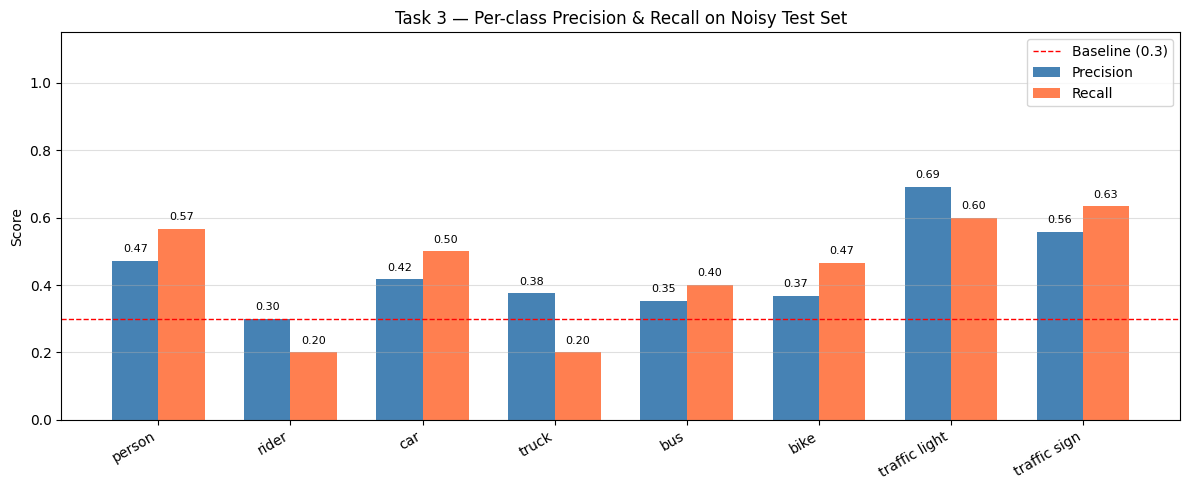

In [ ]:
# 3. visualize the per-class metrics in a single figure

x = np.arange(NUM_CLASSES)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

b1 = ax.bar(x - width/2, precision_per_class, width, label="Precision", color="steelblue")
b2 = ax.bar(x + width/2, recall_per_class,    width, label="Recall",    color="coral")

for bar in [*b1, *b2]:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.2f}",
        ha="center", va="bottom", fontsize=8,
    )

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Task 3 — Per-class Precision & Recall on Noisy Test Set")
ax.axhline(0.3, color="red", linestyle="--", linewidth=1, label="Baseline (0.3)")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

In [49]:
# 4. aggregate the per-class metrics across all classes on the corrupted test set. Then re-
# evaluate the model on the clean test set without the PatchShuffle corruption transformation
# and report the resulting aggregated metrics for both test sets (4 scalar values)

# Report 4 scalar values:
#             1. Macro-precision  — noisy test set
#             2. Macro-recall     — noisy test set
#             3. Macro-precision  — clean test set
#             4. Macro-recall     — clean test set
#
# Macro-average: compute the metric per class, then take the
# UNWEIGHTED mean across all 8 classes. Every class contributes
# equally regardless of how many samples it has.

macro_p_noisy = precision_score(labels_noisy, preds_noisy, average="macro", zero_division=0)
macro_r_noisy = recall_score(labels_noisy, preds_noisy, average="macro", zero_division=0)

# Clean: run inference again with the clean test loader (no PatchShuffle)
preds_clean, labels_clean = get_preds_and_labels(model, test_loader_clean, DEVICE)
macro_p_clean = precision_score(labels_clean, preds_clean, average="macro", zero_division=0)
macro_r_clean = recall_score(labels_clean, preds_clean, average="macro", zero_division=0)



print("\nAggregated metrics (macro-average across all classes):")
print("=" * 50)
print(f"{'':20s} {'Precision':>12} {'Recall':>12}")
print("-" * 50)
print(f"{'Noisy test set':20s} {macro_p_noisy:>12.4f} {macro_r_noisy:>12.4f}")
print(f"{'Clean test set':20s} {macro_p_clean:>12.4f} {macro_r_clean:>12.4f}")
print("=" * 50)


Aggregated metrics (macro-average across all classes):
                        Precision       Recall
--------------------------------------------------
Noisy test set             0.4646       0.4625
Clean test set             0.4646       0.4625


## Task 3

In [15]:
import torchvision.models as models
from sklearn.neighbors import KNeighborsClassifier

In [16]:
# This utility class is aimed to help you a bit with the linear probe classifier.
# You can choose whether to implement it or not!


class LinearProbeClassifier(nn.Module):
    """
    Frozen pretrained backbone + trainable linear classification head.

    TODO:
    - load a pretrained backbone,
    - remove/replace its original classification head (if any),
    - freeze the backbone parameters,
    - add a new trainable linear head for the BDD classes.
    """

    def __init__(self, backbone_arch: str, num_classes: int):
        super().__init__()

        self.backbone = getattr(models, backbone_arch)(pretrained=True)
        # TODO: Sometimes the pretrained backbone may already have a classification head (e.g. ResNet's fc layer, ViT's heads layer). In this case you might need to replace it with an Identity layer to get the features before the head.
        # The Identity layer is simply a placeholder for the Identity function, which returns its input unchanged.
        self.backbone.heads = nn.Identity()
        # TODO: freeze all pretrained backbone parameters. Freezing a parameter means that it will not be updated during gradient updates.
        for param in self.backbone.parameters():
            param.requires_grad = False
        # TODO: define the trainable linear classification head
        feature_dim = self.backbone.hidden_dim
        self.linear_head = nn.Linear(feature_dim, num_classes)


    def forward(self, x: torch.Tensor):
        # The backbone should be used as a feature extractor.
        features = self.backbone(x)
        # Then the features from the backbone are passed through the linear head to get the final logits for classification.
        logits = self.linear_head(features)
        return logits


In [17]:
model = LinearProbeClassifier(
    backbone_arch="vit_b_16",
    num_classes=NUM_CLASSES
).to(DEVICE)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:06<00:00, 56.2MB/s]


In [18]:
def extract_features(model, dataloader, DEVICE):
    model.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(DEVICE)
            features = model.backbone(x)

            all_features.append(features.cpu())
            all_labels.append(y)

    all_features = torch.cat(all_features, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    return all_features, all_labels

In [22]:
IMG_SIZE = 224

train_transform_vit = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor(),
    Normalize(mean=MEAN, std=STD),
])


# same as training, no corruption
test_transform_vit = Compose([
    Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor(),
    Normalize(mean=MEAN, std=STD),
])


train_dataset_vit = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=train_transform_vit,
)



test_dataset_vit = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=test_transform_vit,
)

In [26]:

train_loader_vit = DataLoader(train_dataset_vit, batch_size=BATCH_SIZE, shuffle=True)
test_loader_vit = DataLoader(test_dataset_vit, batch_size=BATCH_SIZE, shuffle=False)

In [27]:
train_features, train_labels = extract_features(model, train_loader_vit, DEVICE)
test_features, test_labels = extract_features(model, test_loader_vit, DEVICE)

In [28]:
print(train_features.shape)
print(test_features.shape)

torch.Size([2400, 768])
torch.Size([240, 768])


In [32]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.linear_head.parameters(),lr=1e-3)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader_vit:
        x = x.to(DEVICE)
        y = y.to(DEVICE)


        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, loss: {total_loss / len(train_loader):.4f}")

Epoch 1/10, loss: 1.2522
Epoch 2/10, loss: 0.8799
Epoch 3/10, loss: 0.7714
Epoch 4/10, loss: 0.7054
Epoch 5/10, loss: 0.6511
Epoch 6/10, loss: 0.6171
Epoch 7/10, loss: 0.5761
Epoch 8/10, loss: 0.5525
Epoch 9/10, loss: 0.5303
Epoch 10/10, loss: 0.5062


In [42]:
#Linear probing model predictions
preds_lb,labels = get_preds_and_labels(  model, test_loader_vit, DEVICE)
#

In [38]:
train=_features = train_features.numpy()
train_labels = train_labels.numpy()
test_features = test_features.numpy()
test_labels = test_labels.numpy()

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_features, train_labels)

knn_preds = knn.predict(test_features)




array([3, 1, 4, 7, 2, 2, 3, 4, 0, 2, 6, 0, 1, 3, 4, 6, 3, 2, 5, 3, 5, 5,
       1, 0, 7, 1, 2, 6, 1, 0, 5, 4, 6, 0, 0, 6, 4, 6, 1, 3, 5, 6, 7, 7,
       5, 2, 3, 3, 1, 2, 6, 4, 6, 7, 7, 7, 1, 0, 5, 7, 0, 1, 2, 4, 1, 5,
       5, 3, 7, 2, 0, 0, 6, 1, 4, 6, 6, 2, 2, 2, 4, 1, 6, 6, 0, 4, 2, 2,
       7, 1, 1, 2, 0, 2, 2, 6, 1, 0, 3, 7, 7, 6, 7, 4, 1, 6, 2, 1, 4, 7,
       2, 6, 5, 0, 3, 7, 2, 7, 5, 7, 5, 2, 2, 0, 6, 6, 0, 2, 0, 5, 3, 2,
       2, 6, 0, 2, 5, 0, 3, 6, 0, 6, 7, 2, 4, 6, 6, 1, 2, 4, 7, 3, 2, 5,
       7, 7, 6, 5, 0, 4, 2, 5, 5, 2, 0, 6, 2, 7, 6, 4, 6, 7, 6, 4, 7, 0,
       3, 2, 6, 5, 7, 2, 6, 0, 0, 1, 0, 5, 7, 1, 2, 7, 3, 1, 6, 6, 6, 2,
       4, 5, 6, 4, 7, 0, 2, 0, 6, 7, 7, 0, 6, 4, 1, 7, 0, 4, 2, 1, 0, 0,
       4, 6, 1, 7, 3, 2, 2, 2, 0, 0, 2, 5, 5, 5, 7, 5, 2, 5, 0, 6])

In [43]:
#knn aggeragated metrics
macro_p_knn = precision_score(test_labels, knn_preds, average="macro", zero_division=0)
macro_r_knn = recall_score(test_labels, knn_preds, average="macro", zero_division=0)

#Linear probing aggeragated metrics
macro_p_lb = precision_score(test_labels, preds_lb, average="macro", zero_division=0)
macro_r_lb = recall_score(test_labels, preds_lb, average="macro", zero_division=0)



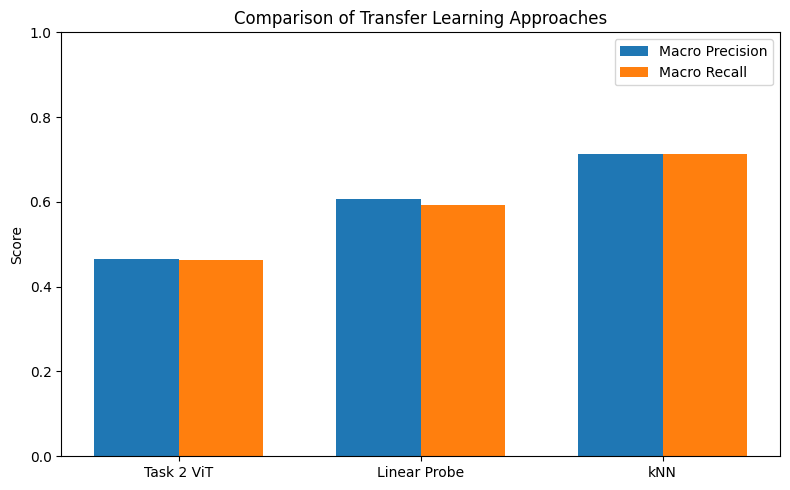

In [53]:
precision = [ macro_p_clean, macro_p_knn, macro_p_lb]
recall = [macro_r_clean, macro_r_knn, macro_r_lb]
plt.figure(figsize=(8,5))

width = 0.35
methods = ["Task 2 ViT", "Linear Probe", "kNN"]
x = np.arange(len(methods))
plt.bar(x - width/2, precision, width, label="Macro Precision")
plt.bar(x + width/2, recall, width, label="Macro Recall")



plt.xticks(x, methods)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Comparison of Transfer Learning Approaches")
plt.legend()

plt.tight_layout()
plt.show()